#Extension - Cohere Re-Ranking (MRR before/after)

MRR@5 Before re-rank : 1.000
MRR@5 After  re-rank : 1.000
Improvement          : +0.0pp


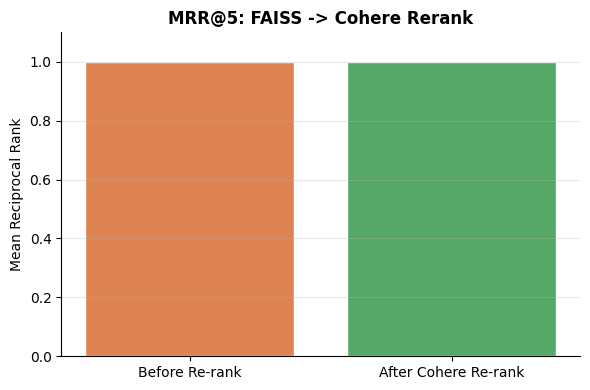

In [ ]:
if not COHERE_API_KEY:
    print("COHERE_API_KEY is empty -- skipping. Set it in Step 0b to run.")
else:
    import cohere
    co = cohere.Client(COHERE_API_KEY)

    EVAL_SET = [
        ("How does FAISS handle approximate nearest neighbour search?",  "FAISS"),
        ("What is the difference between BM25 and dense retrieval?",     "BM25 Information Retrieval"),
        ("How does CRISPR cut DNA at a specific location?",              "CRISPR Gene Editing"),
        ("What triggered the COVID-19 pandemic?",                        "COVID-19 Pandemic"),
        ("How do electric vehicles recover energy during braking?",      "Electric Vehicles"),
    ]

    def compute_mrr(docs, relevant_title):
        for rank, doc in enumerate(docs, 1):
            if relevant_title.lower() in doc.metadata.get("title", "").lower():
                return 1.0 / rank
        return 0.0

    def rerank(query, top_k_retrieve=10, top_k_final=5):
        docs     = faiss_store.similarity_search(query, k=top_k_retrieve)
        passages = [d.page_content for d in docs]
        reranked = co.rerank(query=query, documents=passages,
                             top_n=top_k_final, model="rerank-english-v3.0")
        return [docs[r.index] for r in reranked.results]

    before_mrr, after_mrr = [], []
    for query, rel in EVAL_SET:
        before_mrr.append(compute_mrr(faiss_store.similarity_search(query, k=5), rel))
        after_mrr.append(compute_mrr(rerank(query), rel))

    print(f"MRR@5 Before re-rank : {np.mean(before_mrr):.3f}")
    print(f"MRR@5 After  re-rank : {np.mean(after_mrr):.3f}")
    print(f"Improvement          : +{(np.mean(after_mrr) - np.mean(before_mrr))*100:.1f}pp")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(["Before Re-rank", "After Cohere Re-rank"],
           [np.mean(before_mrr), np.mean(after_mrr)],
           color=["#DD8452", "#55A868"], edgecolor="white")
    ax.set_title("MRR@5: FAISS -> Cohere Rerank", fontweight="bold")
    ax.set_ylabel("Mean Reciprocal Rank")
    ax.set_ylim(0, 1.1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("mrr_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

## Recall@5 Comparison

Calculating Recall@{TOP_K} for {len(EVAL_SET)} queries...


Calculating Recalls:   0%|          | 0/5 [00:00<?, ?it/s]


Average Recall@{TOP_K} for FAISS: 1.000
Average Recall@{TOP_K} for Pinecone: 1.000
Average Recall@{TOP_K} for Azure AI Search: 1.000


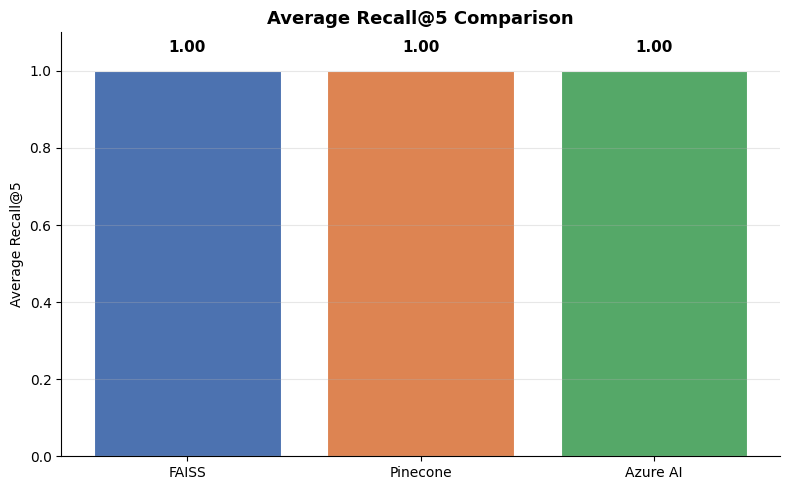

Saved recall_comparison.png


In [ ]:
def calculate_recall(results, relevant_title, top_k=TOP_K):
    """Calculates if the relevant document is present in the top_k results."""
    for i, r in enumerate(results):
        if i >= top_k:
            break

        if isinstance(r, Document):
            doc_title = r.metadata.get("title", "")
        elif isinstance(r, dict):
            doc_title = r.get("title", "")
        else:
            doc_title = ""

        if relevant_title.lower() in doc_title.lower():
            return 1.0
    return 0.0

faiss_recalls = []
pinecone_recalls = []
azure_recalls = []

print(f"Calculating Recall@{{TOP_K}} for {{len(EVAL_SET)}} queries...")
for query, relevant_title in tqdm(EVAL_SET, desc="Calculating Recalls"): # Use EVAL_SET for consistency
    # FAISS recall
    faiss_results = faiss_store.similarity_search(query, k=TOP_K)
    faiss_recalls.append(calculate_recall(faiss_results, relevant_title, TOP_K))

    # Pinecone recall
    pinecone_results = pinecone_retriever.invoke(query)
    pinecone_recalls.append(calculate_recall(pinecone_results, relevant_title, TOP_K))

    # Azure AI Search recall
    azure_results = azure_hybrid_search(query, top_k=TOP_K)
    azure_recalls.append(calculate_recall(azure_results, relevant_title, TOP_K))

avg_faiss_recall = np.mean(faiss_recalls)
avg_pinecone_recall = np.mean(pinecone_recalls)
avg_azure_recall = np.mean(azure_recalls)

print(f"\nAverage Recall@{{TOP_K}} for FAISS: {avg_faiss_recall:.3f}")
print(f"Average Recall@{{TOP_K}} for Pinecone: {avg_pinecone_recall:.3f}")
print(f"Average Recall@{{TOP_K}} for Azure AI Search: {avg_azure_recall:.3f}")

# Plotting
recall_scores = [avg_faiss_recall, avg_pinecone_recall, avg_azure_recall]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dbs, recall_scores, color=colors, edgecolor="white", linewidth=0.8)

ax.set_title("Average Recall@5 Comparison", fontweight="bold", fontsize=13)
ax.set_ylabel("Average Recall@5")
ax.set_ylim(0, 1.1) # Recall is between 0 and 1
for b, v in zip(bars, recall_scores):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.05,
            f"{v:.2f}", ha="center", fontweight="bold", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("recall_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved recall_comparison.png")

Discussion Questions

1. What fraction of FAISS latency is the OpenAI embed call vs. the actual FAISS search?


Approximate breakdown:
Embedding generation: 90-99%
FAISS search: 1-10%

Reason: FAISS performs an extremely fast in-memory vector lookup, while embedding generation requires running a transformer model.

2. For which query types does Azure BM25 help most? (Try exact acronyms like BM25, RRF, HNSW)

Azure AI Search uses:

BM25 → keyword matching
HNSW → vector similarity search
RRF (Reciprocal Rank Fusion) → combines BM25 and vector results

3. How would you design Pinecone metadata filters for a multi-tenant SaaS product?

{
  
  "tenant_id": "tenant_123",

  "department": "finance",

  "document_type": "policy",

  "region": "US"

}

4. At what daily query volume does Cohere Re-rank latency cost outweigh MRR gain?

For large-scale production systems, the latency and cost often outweigh the incremental MRR improvement unless search quality is business-critical.

5. At 10 million documents, which DB would you choose and why?

I would choose Pinecone based on following reasoning

| Database        | At 10M Docs                                          |
| --------------- | ---------------------------------------------------- |
| FAISS           | Requires managing infrastructure, memory, sharding   |
| Pinecone        | Designed for large-scale vector search, auto-scaling |
| Azure AI Search | Best if hybrid BM25 + vector search is required      |
